In [1]:
# Setup paths and load libraries
path_to_lucas <- "../../data/reproduce_lucas_wflow"
directory_path <- "../../"

dir.create("../../outputs/Extended", recursive = TRUE, showWarnings = FALSE)

suppressMessages({
    library(SummarizedExperiment)
    library(magrittr)
    library(stringr)
    library(tidyverse)
    library(grid)
    library(lemon)
    library(gridExtra)
    library(cowplot)
    library(data.table)
    library(pROC)
    library(RColorBrewer)
    library(here)
    library(rlucas)
    library(ggsci)
})

source(file.path(path_to_lucas, "code/plot-roc.r"))
data(se, package="rlucas")
rename <- dplyr::rename

In [2]:
metadata <- colData(se) %>% as_tibble()
meta_mica <- read_csv(file.path(directory_path, "data/mica_meta.csv"), show_col_types=FALSE)

load(file.path(directory_path, "models_code/FINAL/train_preds_lucas_c1_FULL.rda"))

# Set to TRUE to show the grey vertical line at 0.80 specificity in ROC curves
SHOW_SPECIFICITY_LINE <- FALSE

## Prepare Model Data

In [3]:
model_levels <- c("DELFI", "Proteomics", "DELFI-Pro Lung")

prepare_model_data <- function(preds, score_col, model_name, metadata) {
    preds %>%
        filter(!is.na(!!sym(score_col))) %>%
        select(id, !!sym(score_col)) %>%
        set_colnames(c("pgdx_id", "score")) %>%
        mutate(training_model = model_name) %>%
        left_join(metadata %>% select(lab_id, pgdx_id), by = "pgdx_id") %>%
        select(-pgdx_id) %>%
        select(lab_id, everything())
}

dat1 <- prepare_model_data(preds, "score.seq", model_levels[1], metadata)
dat2 <- prepare_model_data(preds, "score.olink.only", model_levels[2], metadata)
dat3 <- prepare_model_data(preds, "score.seq.olink", model_levels[3], metadata)

dat <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels))

combined <- fig3_data(se, dat1, dat2, dat3)

performance_at_cutoff <- function(x, cutoff) {
    robj <- pROC::roc(class ~ score, x, ret = TRUE, quiet = TRUE)
    tibble(sens = robj$sens, spec = robj$spec, thresholds = robj$thresholds) %>%
        filter(thresholds >= cutoff) %>%
        arrange(thresholds) %>%
        slice(1)
}

In [4]:
nocancer_labels <- c("no baseline cancer", "benign",
                     "no lung cancer, other cancer",
                     "no lung cancer, later lung cancer")

clindat <- fig3_clindat(se)

overall <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels)) %>%
    left_join(clindat, by = "lab_id") %>%
    mutate(class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
           class = factor(class, c("No cancer", "Cancer")))

overall.list <- split(overall, overall$training_model)

In [5]:
load(file.path(directory_path, "models_code/FINAL/calibration_set_mica_c1_FULL.rda"))
load(file.path(directory_path, "models_code/FINAL/test_val_mica_c1_FULL.rda"))
load(file.path(directory_path, "models_code/FINAL/test_preds_lucas_c1_FULL.rda"))

In [6]:
# Quantile mapping corrects technical batch shift between LUCAS and MICA. The
# mapping is learned from non-cancer samples only:
#   Reference: LUCAS training CV predictions (via dat1/dat2/dat3)
#   Source:    MICA calibration set (preds_mica_cal) — all healthy
# After calibration MICA scores are on the LUCAS scale, so one LUCAS-derived
# threshold applies uniformly.

lucas_train_nocancer <- bind_rows(dat1, dat2, dat3) %>%
    left_join(clindat, by = "lab_id") %>%
    filter(patient_type %in% nocancer_labels)

lucas_nocancer_seq       <- lucas_train_nocancer %>% filter(training_model == model_levels[1]) %>% pull(score)
lucas_nocancer_olink     <- lucas_train_nocancer %>% filter(training_model == model_levels[2]) %>% pull(score)
lucas_nocancer_seq_olink <- lucas_train_nocancer %>% filter(training_model == model_levels[3]) %>% pull(score)

mica_cal_nocancer <- preds_mica_cal

build_quantile_mapper <- function(source_scores, reference_scores, n_quantiles = 500) {
    probs <- seq(0, 1, length.out = n_quantiles)
    source_q <- quantile(source_scores, probs = probs, na.rm = TRUE)
    ref_q    <- quantile(reference_scores, probs = probs, na.rm = TRUE)
    function(new_scores) {
        approx(x = source_q, y = ref_q, xout = new_scores, rule = 2)$y
    }
}

mapper_seq <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.seq.test,
    reference_scores = lucas_nocancer_seq
)
mapper_olink <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.olink.only.test,
    reference_scores = lucas_nocancer_olink
)
mapper_seq_olink <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.seq.olink.test,
    reference_scores = lucas_nocancer_seq_olink
)

cat("Quantile mappers built from:\n")
cat("  LUCAS training non-cancer:", length(lucas_nocancer_seq), "samples\n")
cat("  MICA calibration non-cancer:", nrow(mica_cal_nocancer), "samples\n\n")

# ---- LUCAS test set ----------------------------------------------------
lucas_val <- preds_test %>%
    left_join(metadata %>% select(lab_id, pgdx_id), by = c("id" = "pgdx_id")) %>%
    left_join(clindat %>% select(lab_id, patient_type, stage), by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        ),
        cohort = "LUCAS",
        score.seq       = score.seq.test,
        score.olink     = score.olink.only.test,
        score.seq.olink = score.seq.olink.test
    ) %>%
    select(id, lab_id, cohort, class, stage, stage_combined,
           score.seq, score.olink, score.seq.olink)

# ---- calibrated MICA validation set ------------------------------------
mica_val <- preds_mica_validation %>%
    select(-any_of(c("type", "Stage", "stage"))) %>%
    left_join(
        meta_mica %>% select(id, type, Stage) %>%
            mutate(type = as.character(type), Stage = as.character(Stage)),
        by = "id"
    ) %>%
    mutate(
        class = ifelse(type == "healthy", "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage = Stage,
        stage_combined = case_when(
            Stage %in% c("I", "II")   ~ "I/II",
            Stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        ),
        cohort = "MICA",
        score.seq       = mapper_seq(score.seq.test),
        score.olink     = mapper_olink(score.olink.only.test),
        score.seq.olink = mapper_seq_olink(score.seq.olink.test)
    ) %>%
    select(id, cohort, class, stage, stage_combined,
           score.seq, score.olink, score.seq.olink)

combined_val <- bind_rows(lucas_val, mica_val)

cat("Combined validation set:\n")
cat("  LUCAS:", nrow(lucas_val), "samples\n")
cat("  MICA: ", nrow(mica_val),  "samples\n")
cat("  Total:", nrow(combined_val), "samples\n\n")

combined_val %>% count(cohort, class) %>%
    pivot_wider(names_from = class, values_from = n) %>% print()

combined_val %>% filter(class == "Cancer") %>%
    count(cohort, stage_combined) %>%
    pivot_wider(names_from = stage_combined, values_from = n, values_fill = 0) %>% print()

Quantile mappers built from:
  LUCAS training non-cancer: 84 samples
  MICA calibration non-cancer: 40 samples

Combined validation set:
  LUCAS: 65 samples
  MICA:  360 samples
  Total: 425 samples

# A tibble: 2 × 3
  cohort `No cancer` Cancer
  <chr>        <int>  <int>
1 LUCAS           40     25
2 MICA           344     16
# A tibble: 2 × 3
  cohort `I/II` `III/IV`
  <chr>   <int>    <int>
1 LUCAS       5       20
2 MICA        3       13


In [7]:
# =============================================================================
# Combined validation figure with locked LUCAS training thresholds
# =============================================================================
create_combined_validation_figure <- function(
    combined_val,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80),
    models_to_plot = c("DELFI", "DELFI-Pro"),
    validation_set = "combined",
    se_level = 0.95,
    plot_width = 12,
    plot_height = 12
) {

    # ── Validate inputs ──────────────────────────────────────────────────
    valid_val_options <- c("combined", "lucas_test", "mica")
    if (!all(validation_set %in% valid_val_options)) {
        stop(paste("Invalid validation_set option(s). Valid options are:",
                   paste(valid_val_options, collapse = ", ")))
    }

    # ── Facet label formatter (single source of truth) ──────────────────
    spec_label <- function(cutoff) paste0("Spec. ", round(cutoff * 100), "%")

    # ── Model configuration ──────────────────────────────────────────────
    model_map <- list(
        "DELFI" = list(
            idx = 1, dat = dat1,
            score_col = "score.seq",
            display_name = "DELFI"
        ),
        "Proteomics" = list(
            idx = 2, dat = dat2,
            score_col = "score.olink",
            display_name = "Proteomics"
        ),
        "DELFI-Pro" = list(
            idx = 3, dat = dat3,
            score_col = "score.seq.olink",
            display_name = "DELFI-Pro"
        )
    )

    valid_models <- names(model_map)
    if (!all(models_to_plot %in% valid_models)) {
        stop(paste("Invalid model name(s). Valid options are:",
                   paste(valid_models, collapse = ", ")))
    }

    n_cutoffs <- length(specificity_cutoffs)
    n_models  <- length(models_to_plot)
    if (is.null(plot_height)) {
        plot_height <- max(8, n_cutoffs * 3 + 1)
    }

    alpha          <- 1 - se_level
    lower_quantile <- alpha / 2
    upper_quantile <- 1 - alpha / 2

    # ── Helper: clean a validation subset ───────────────────────────────
    clean_val <- function(df) {
        df %>%
            mutate(
                stage_combined = case_when(
                    class == "No cancer"              ~ NA_character_,
                    stage_combined %in% "I/II"        ~ "I/II",
                    stage_combined %in% "III/IV"      ~ "III/IV",
                    TRUE                              ~ NA_character_
                )
            )
    }

    # ── Build validation set list ────────────────────────────────────────
    val_sets <- list()
    if ("combined" %in% validation_set) {
        val_sets[["Combined (LUCAS test + MICA)"]] <- clean_val(combined_val)
    }
    if ("lucas_test" %in% validation_set) {
        val_sets[["Test (LUCAS)"]] <- combined_val %>%
            filter(cohort == "LUCAS") %>%
            clean_val()
    }
    if ("mica" %in% validation_set) {
        val_sets[["Validation (MICA)"]] <- combined_val %>%
            filter(cohort == "MICA") %>%
            clean_val()
    }

    cat("Datasets to evaluate:\n")
    cat("  Training (LUCAS): used for threshold derivation + shown in plot\n")
    for (nm in names(val_sets)) {
        d <- val_sets[[nm]]
        cat(sprintf("  %s: %d samples (%d no cancer, %d cancer)\n",
                    nm, nrow(d),
                    sum(d$class == "No cancer"), sum(d$class == "Cancer")))
    }
    cat("\n")

    # ── LUCAS training data (for threshold derivation ONLY) ──────────────
    overall <- bind_rows(dat1, dat2, dat3) %>%
        mutate(training_model = factor(training_model, model_levels)) %>%
        left_join(clindat, by = "lab_id") %>%
        mutate(
            class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
            class = factor(class, c("No cancer", "Cancer")),
            stage_combined = case_when(
                stage %in% c("I", "II")   ~ "I/II",
                stage %in% c("III", "IV") ~ "III/IV",
                TRUE                      ~ NA_character_
            )
        )
    overall.list <- split(overall, overall$training_model)

    # ── Helper: evaluate a dataset at a locked threshold ─────────────────
    evaluate_at_threshold <- function(data, score_col, threshold,
                                      lower_q, upper_q) {

        conf_level <- 2 * upper_q - 1

        scores <- data %>%
            select(class, stage = stage_combined, score = !!sym(score_col)) %>%
            filter(!is.na(score))

        # Specificity
        nocancer <- scores %>% filter(class == "No cancer")
        n_nc     <- nrow(nocancer)
        tn       <- sum(nocancer$score < threshold)
        spec_ci  <- prop.test(tn, n_nc, conf.level = conf_level, correct = FALSE)

        # Sensitivity by stage
        stage_perf <- scores %>%
            filter(class == "Cancer", !is.na(stage)) %>%
            group_by(stage) %>%
            summarise(n = n(), tp = sum(score >= threshold), .groups = "drop") %>%
            rowwise() %>%
            mutate(
                ci    = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE)),
                sens  = ci$estimate,
                lower = ci$conf.int[1],
                upper = ci$conf.int[2]
            ) %>%
            select(-ci) %>%
            ungroup()

        bind_rows(
            tibble(
                stage = "0", value = unname(spec_ci$estimate), n = n_nc,
                lower = spec_ci$conf.int[1], upper = spec_ci$conf.int[2],
                statistic = "Specificity"
            ),
            stage_perf %>% transmute(
                stage, value = sens, n,
                lower, upper,
                statistic = "Sensitivity"
            )
        )
    }

    # ── Main loop ────────────────────────────────────────────────────────
    all_perf <- list()

    for (spec_cutoff in specificity_cutoffs) {
        for (model_name in models_to_plot) {
            model_info <- model_map[[model_name]]

            # ── Lock threshold from LUCAS TRAINING ROC ───────────────────
            lucas_roc_data <- overall.list[[model_info$idx]] %>%
                select(score, class)
            tmp <- pROC::roc(class ~ score, data = lucas_roc_data,
                             ret = TRUE, quiet = TRUE)
            cutoff_row <- tibble(
                sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds
            ) %>%
                filter(spec >= spec_cutoff) %>%
                arrange(spec) %>%
                slice(1)
            locked_threshold <- cutoff_row$thresholds

            # ── Evaluate on LUCAS training set ───────────────────────────
            train_data <- overall.list[[model_info$idx]]
            train_perf <- evaluate_at_threshold(
                train_data, "score", locked_threshold,
                lower_quantile, upper_quantile
            ) %>% mutate(dataset = "Training (LUCAS)")

            all_perf[[paste(spec_cutoff, model_name, "train", sep = "_")]] <- train_perf %>%
                mutate(
                    model              = model_info$display_name,
                    specificity_cutoff = spec_cutoff,
                    specificity_label  = spec_label(spec_cutoff),
                    locked_threshold   = locked_threshold
                )

            # ── Evaluate on each selected validation set ─────────────────
            for (val_name in names(val_sets)) {
                val_perf <- evaluate_at_threshold(
                    val_sets[[val_name]], model_info$score_col, locked_threshold,
                    lower_quantile, upper_quantile
                ) %>% mutate(dataset = val_name)

                all_perf[[paste(spec_cutoff, model_name, val_name, sep = "_")]] <- val_perf %>%
                    mutate(
                        model              = model_info$display_name,
                        specificity_cutoff = spec_cutoff,
                        specificity_label  = spec_label(spec_cutoff),
                        locked_threshold   = locked_threshold
                    )
            }
        }
    }

    # ── Combine all results ──────────────────────────────────────────────
    model_display_levels <- sapply(models_to_plot, function(m) model_map[[m]]$display_name)
    dataset_levels <- c("Training (LUCAS)", names(val_sets))

    combined_perf <- bind_rows(all_perf) %>%
        mutate(
            dataset = factor(dataset, levels = dataset_levels),
            stage = factor(stage, c("0", "I/II", "III/IV")),
            statistic = factor(statistic, c("Specificity", "Sensitivity")),
            specificity_label = factor(
                specificity_label,
                levels = spec_label(sort(specificity_cutoffs))
            ),
            model  = factor(model, levels = model_display_levels),
            stage0 = as.character(stage),
            stage0 = ifelse(stage0 == "0", "Non-Cancer", stage0),
            stage0 = factor(stage0, c("Non-Cancer", "I/II", "III/IV"))
        )

    # ── X-axis labels ────────────────────────────────────────────────────
    if (n_models == 1) {
        combined_perf <- combined_perf %>%
            mutate(
                x_label = case_when(
                    statistic == "Specificity" ~ as.character(model),
                    TRUE ~ as.character(stage0)
                ),
                x_order = case_when(
                    statistic == "Specificity" ~ 1,
                    TRUE ~ as.numeric(stage0)
                )
            )
    } else {
        combined_perf <- combined_perf %>%
            mutate(
                x_label = case_when(
                    statistic == "Specificity" ~ as.character(model),
                    TRUE ~ paste0(stage0, "\n", model)
                ),
                x_order = case_when(
                    statistic == "Specificity" ~ as.numeric(model),
                    TRUE ~ as.numeric(stage0) * 100 + as.numeric(model)
                )
            )
    }

    spec_levels <- combined_perf %>%
        filter(statistic == "Specificity") %>%
        distinct(x_label, x_order) %>% arrange(x_order) %>% pull(x_label)

    sens_levels <- combined_perf %>%
        filter(statistic == "Sensitivity") %>%
        distinct(x_label, x_order) %>% arrange(x_order) %>% pull(x_label)

    spec_perf <- combined_perf %>%
        filter(statistic == "Specificity") %>%
        mutate(x_label = factor(x_label, levels = spec_levels))

    sens_perf <- combined_perf %>%
        filter(statistic == "Sensitivity") %>%
        mutate(x_label = factor(x_label, levels = sens_levels))

    # ── N labels: only for the highest specificity facet ────────────────
    highest_spec_label <- spec_label(max(specificity_cutoffs))

    spec_N <- spec_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        select(x_label, n, dataset, specificity_label)

    sens_N <- sens_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        select(x_label, n, dataset, specificity_label)

    # ── Reference lines ──────────────────────────────────────────────────
    hline_data <- tibble(
        specificity_label = factor(
            spec_label(specificity_cutoffs),
            levels = spec_label(sort(specificity_cutoffs))
        ),
        yintercept = specificity_cutoffs
    )

    # ── Colors ───────────────────────────────────────────────────────────
    all_possible_colors2 <- c(
        "Training (LUCAS)"             = "#808080",
        "Test (LUCAS)"                 = "#9b59b6",
        "Validation (MICA)"            = "#e74c3c",
        "Combined (LUCAS test + MICA)" = "#2ecc71"
    )
    dataset_colors <- all_possible_colors2[dataset_levels]

    # ── Plotting ─────────────────────────────────────────────────────────
    options(repr.plot.width = plot_width, repr.plot.height = plot_height,
            message = FALSE, warning = FALSE)

    n_datasets  <- length(dataset_levels)
    dodge_width <- position_dodge(width = 0.15 * n_datasets + 0.2)

    shared_theme <- theme_classic(base_size = 18) +
        theme(
            panel.grid         = element_blank(),
            panel.background   = element_rect(fill = "white", color = "gray30"),
            strip.background   = element_rect(fill = "gray95", color = "gray30",
                                              linewidth = 0.5),
            strip.text.y.right = element_text(angle = 270, size = 19, color = "black"),
            rect               = element_blank(),
            axis.text          = element_text(size = 19, color = "black"),
            axis.title.x       = element_blank(),
            axis.title.y       = element_text(size = 24)
        )

    shared_y_scale <- scale_y_continuous(
        breaks = seq(0, 1, 0.25),
        labels = scales::percent_format(accuracy = 1),
        limits = c(-0.15, 1.10),
        expand = expansion(add = c(0, 0.02))
    )

    # ── Left panel: Specificity ──────────────────────────────────────────
    p_spec <- ggplot(spec_perf,
                     aes(x = x_label, y = value, group = dataset)) +
        geom_hline(data = hline_data,
                   aes(yintercept = yintercept),
                   linetype = "dotted", color = "gray40", linewidth = 0.5) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = spec_N,
                  aes(x = x_label, y = -0.10, label = paste0(n, "\n")),
                  position = dodge_width, color = "gray20", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(
            legend.position    = "none",
            strip.text.y.right = element_blank(),
            strip.background   = element_blank(),
            axis.text.x        = element_text(size = 30)
        ) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale +
        ylab(" ") +
        ggtitle("Specificity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    # ── Right panel: Sensitivity ─────────────────────────────────────────
    p_sens <- ggplot(sens_perf,
                     aes(x = x_label, y = value, group = dataset)) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = sens_N,
                  aes(x = x_label, y = -0.10, label = paste0(n, "\n")),
                  position = dodge_width, color = "gray30", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(
            legend.position    = "bottom",
            legend.direction   = "horizontal",
            legend.text        = element_text(size = 22),
            strip.background   = element_rect(fill = "gray95", color = "gray20",
                                              linewidth = 0.5),
            strip.text.y.right = element_text(angle = 270, size = 20, color = "black"),
            strip.placement    = "outside",
            axis.text.x        = element_text(size = 30),
            axis.title.y       = element_blank()
        ) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale +
        guides(color = guide_legend(title = "", ncol = 1)) +
        ggtitle("Sensitivity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    # ── Combine panels ───────────────────────────────────────────────────
    right_width <- 1 + n_models * 0.6

    legend <- get_legend(
        p_sens +
            theme(
                legend.position   = "bottom",
                legend.direction  = "horizontal",
                legend.text       = element_text(size = 24,
                                                 margin = margin(l = 10, r = 30, unit = "pt")),
                legend.box.margin = margin(t = 10),
                legend.spacing.x  = unit(2.0, "cm")
            ) +
            guides(color = guide_legend(
                title = "", nrow = 1,
                override.aes = list(size = 5),
                byrow = TRUE
            ))
    )

    p_spec <- p_spec + theme(legend.position = "none")
    p_sens <- p_sens + theme(legend.position = "none")

    plot_row <- plot_grid(
        p_spec, p_sens,
        nrow = 1,
        rel_widths = c(1, right_width),
        align = "h",
        axis  = "tb"
    )

    combined_plot <- plot_grid(
        plot_row, legend,
        ncol = 1,
        rel_heights = c(1, 0.08)
    )

    return(combined_plot)
}


In [8]:
model_info <- list(idx = 3, score_col = "score.seq.olink", display_name = "DELFI-Pro")

overall <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels)) %>%
    left_join(clindat, by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        )
    )
overall.list <- split(overall, overall$training_model)

lucas_roc_data <- overall.list[[model_info$idx]] %>% select(score, class)
tmp <- pROC::roc(class ~ score, data = lucas_roc_data, ret = TRUE, quiet = TRUE)
cutoff_row <- tibble(sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds) %>%
    filter(spec >= 0.60) %>%
    arrange(spec) %>%
    slice(1)
locked_threshold <- cutoff_row$thresholds

print(paste("Locked threshold at 60% specificity:", round(locked_threshold, 4)))

[1] "Locked threshold at 60% specificity: 0.1455"


In [9]:
meta <- meta %>% dplyr::rename(lab_id = Patient)

# Supplementary Fig. 8 - Expanded Spec. Thresholds

Datasets to evaluate:
  Training (LUCAS): used for threshold derivation + shown in plot
  Test (LUCAS): 65 samples (40 no cancer, 25 cancer)
  Validation (MICA): 360 samples (344 no cancer, 16 cancer)



Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In ar

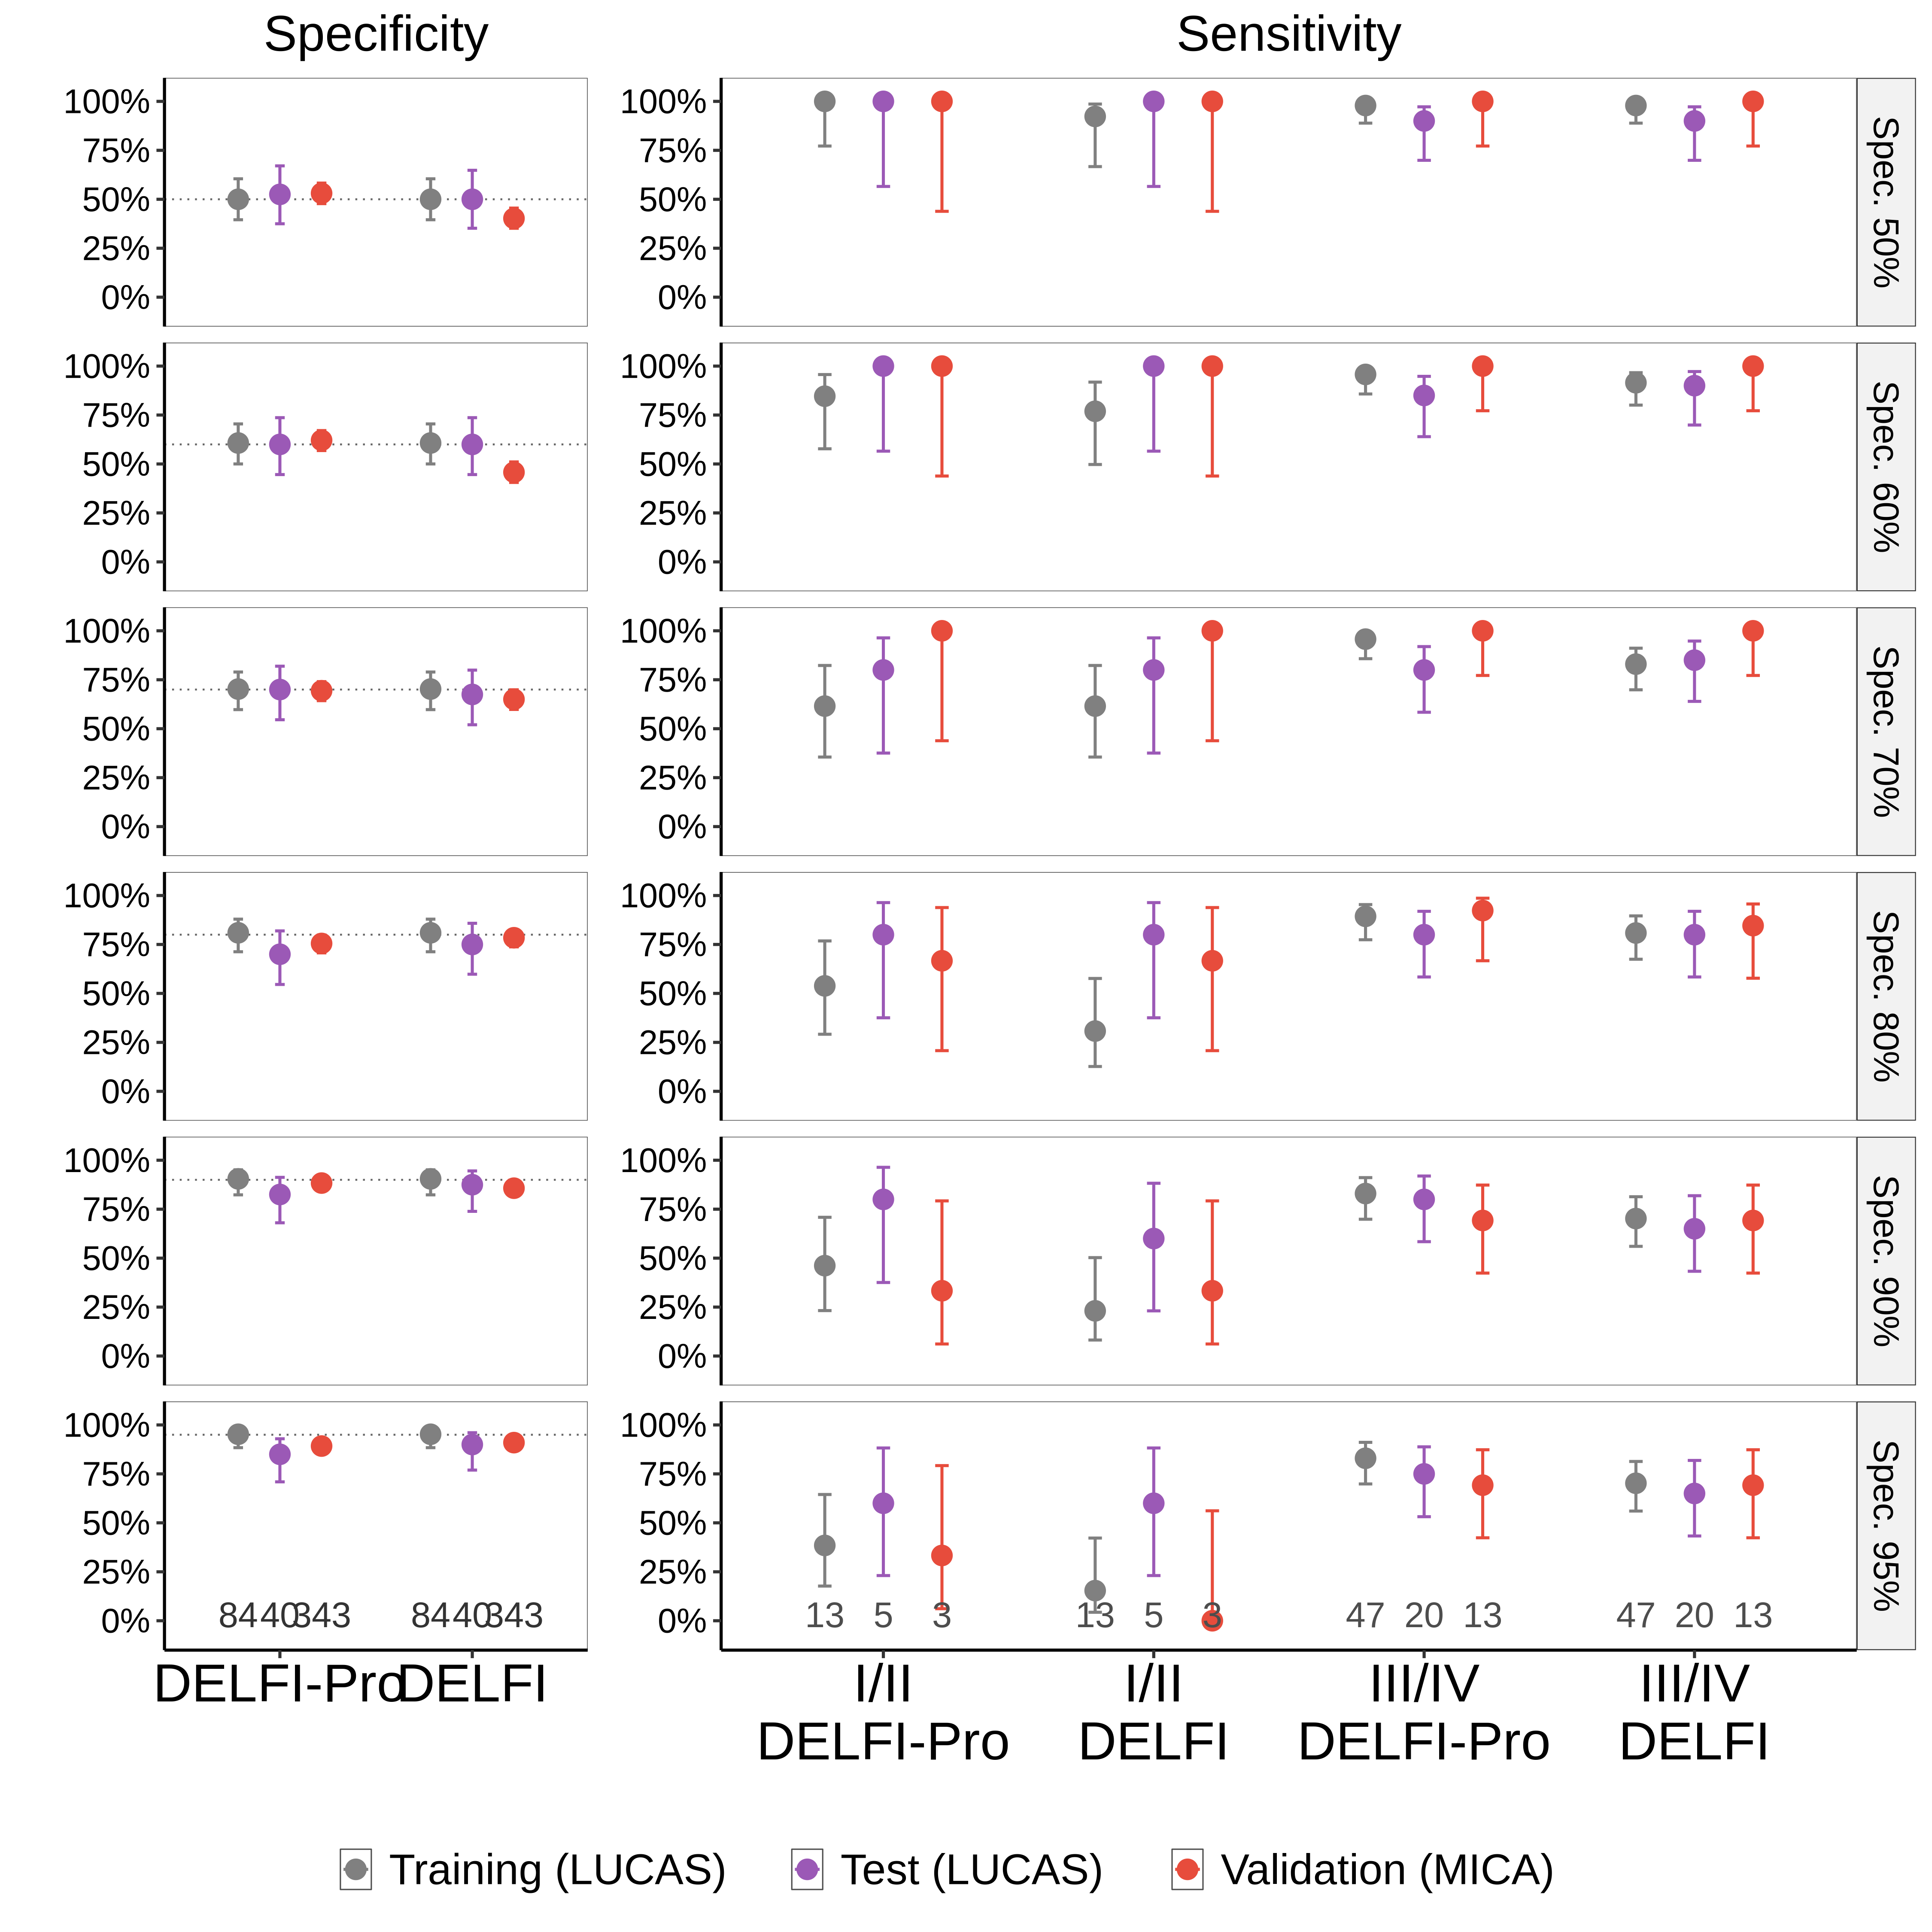

In [10]:
p3 <- create_combined_validation_figure(
    combined_val,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95),
    models_to_plot = c("DELFI-Pro", "DELFI"),
    validation_set = c("lucas_test", "mica"),
    se_level = 0.95,
    plot_width = 12
)

options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 300)

p3

ggsave("../../outputs/Extended/Supple-Fig-8-DELFI-DELFIPRO-Comparison.png",
       plot = p3, width = 20, height = 14, units = "in", dpi = 600)

# Supplementary Fig. 9 - Calibration Analysis

Calibration IDs found in the validation set: 0 (excluded)
Sample set: 360 individuals (344 no cancer, 16 cancer)

MICA validation, DELFI-Pro (raw scores):
  Raw AUC: 0.915 (95% CI 0.859-0.971)

LUCAS-locked threshold (0.1455) applied to RAW MICA:
  spec = 23.9% (n=343), sens = 100.0% (n=16)   [target: 60% spec]
  Discrimination transfers; the score SCALE does not. This gap is what
  the quantile mapping corrects.


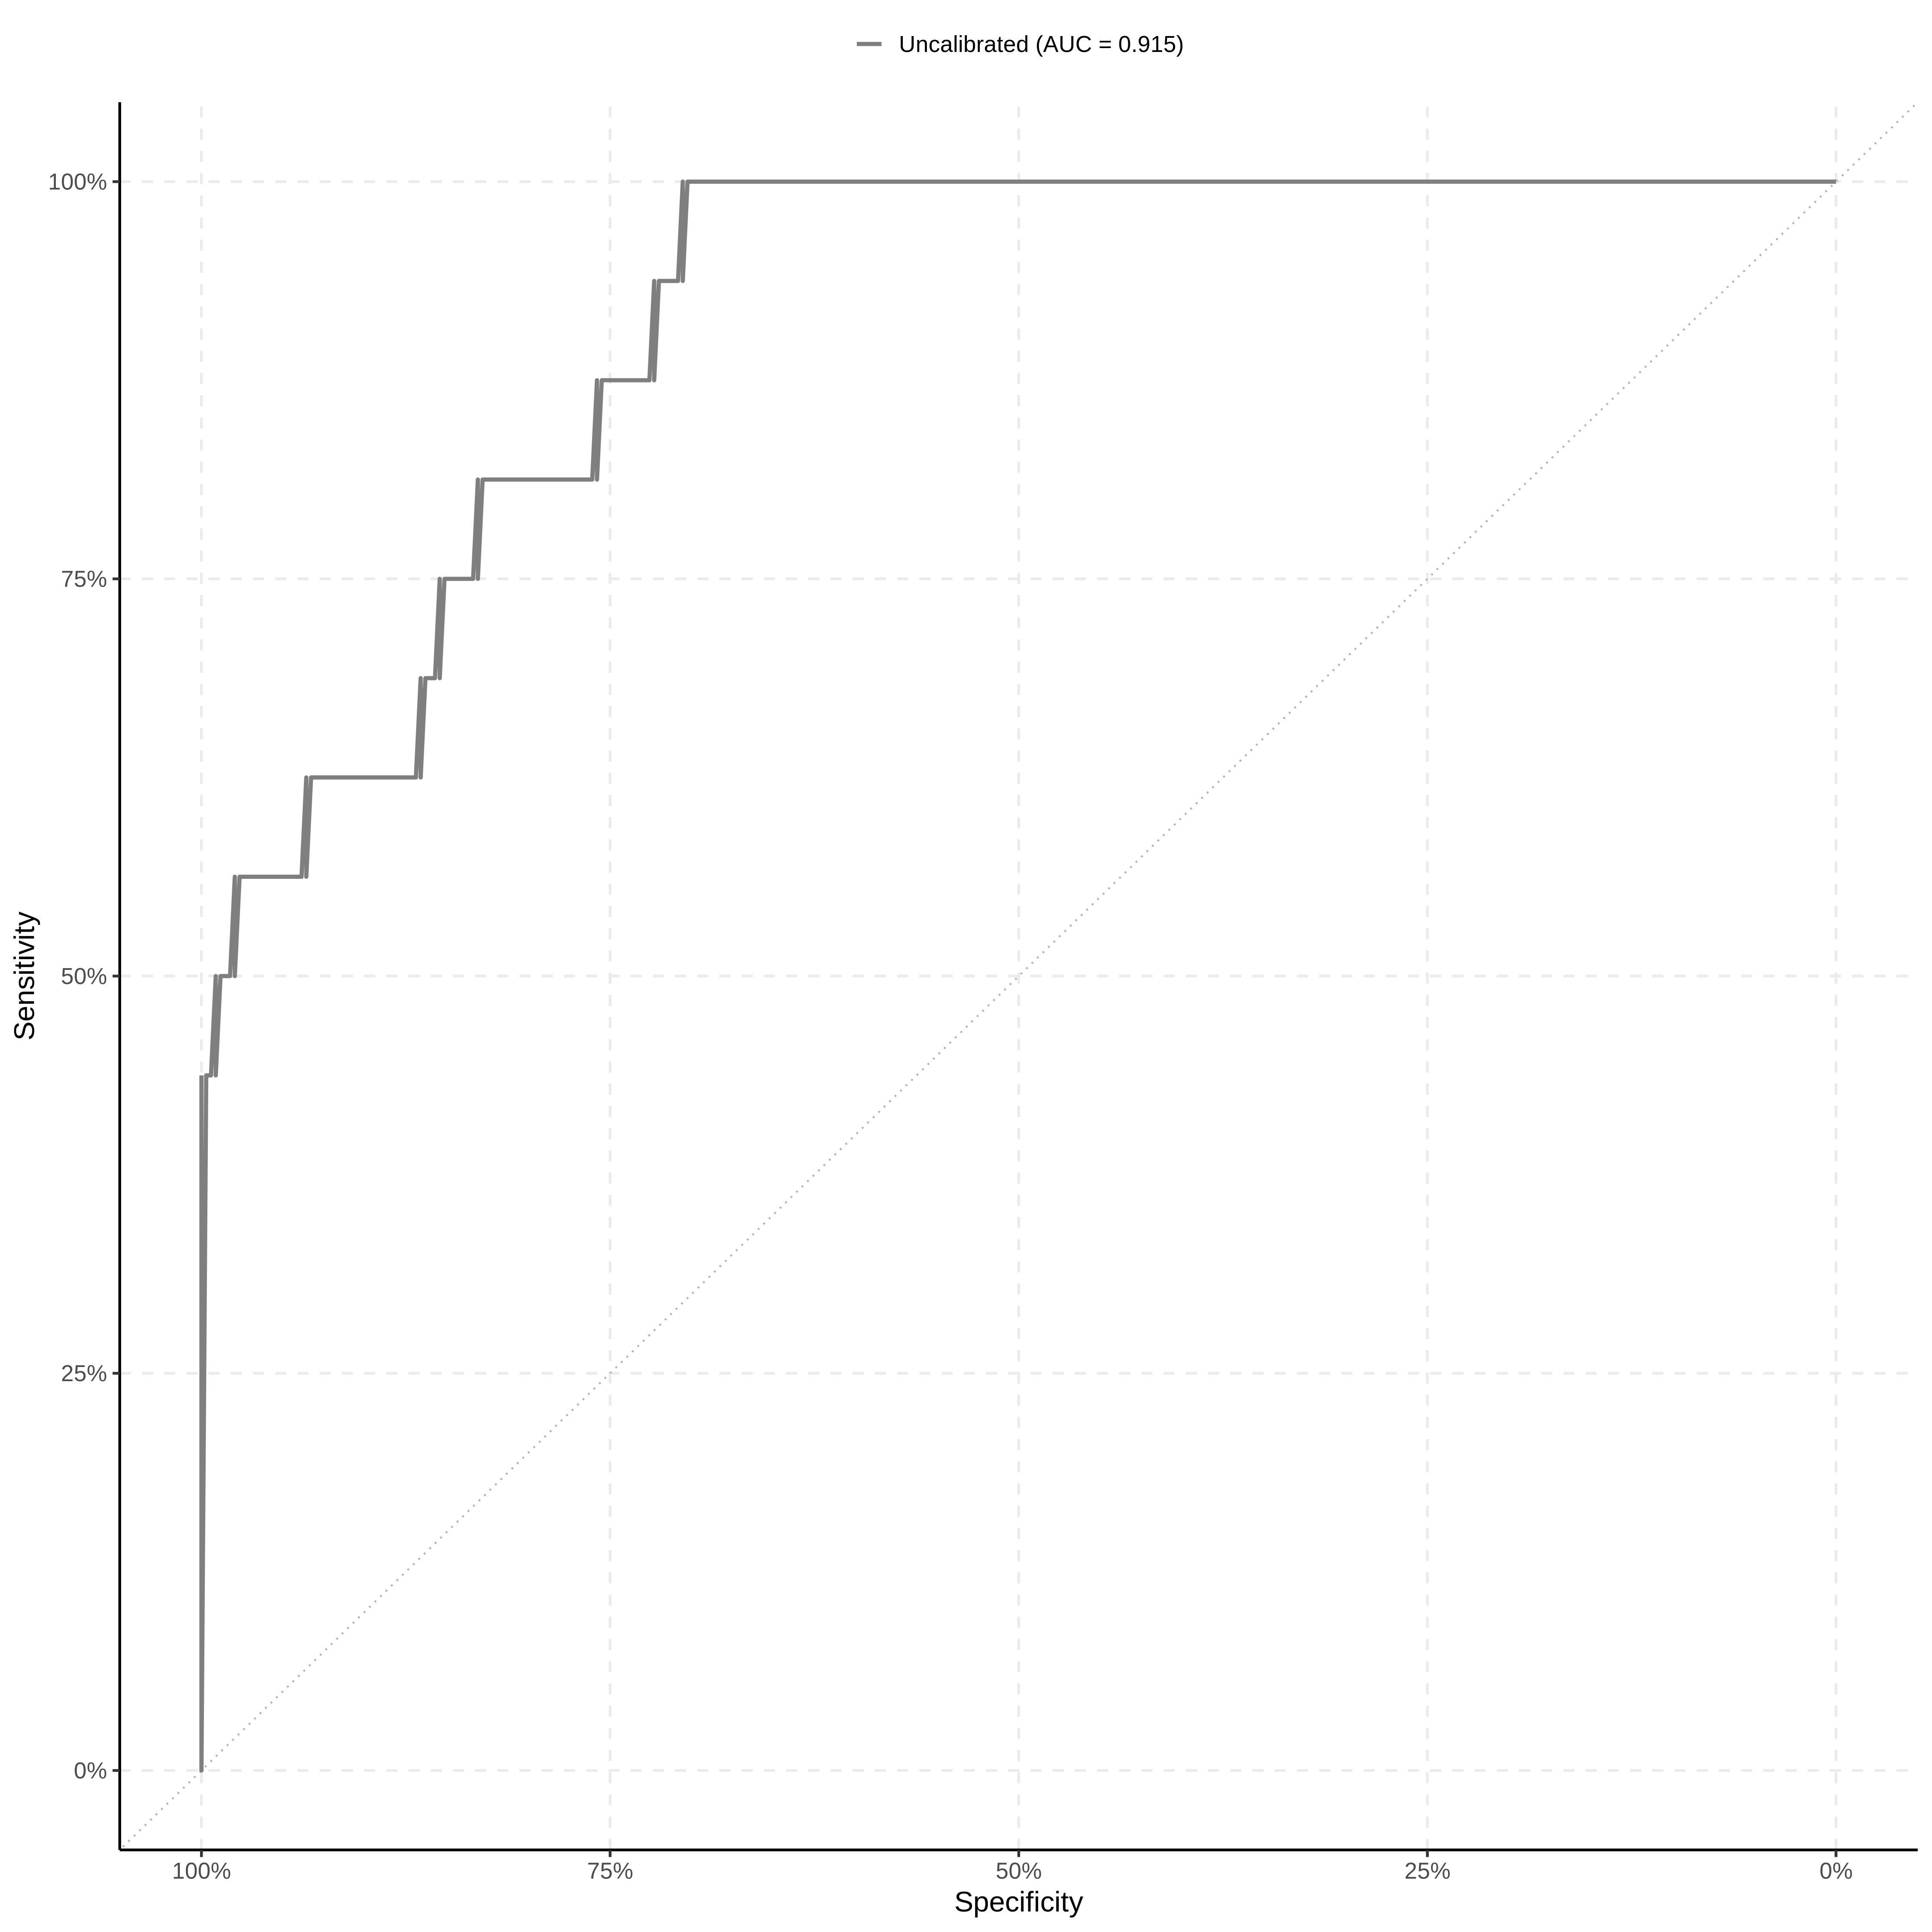

In [11]:
# =====================================================================
# ROC: raw MICA validation scores only
# Shows that discrimination transfers WITHOUT calibration — AUC is
# invariant to any monotone transformation, so quantile mapping cannot
# have inflated it. Specificity at the LUCAS-locked threshold is a
# separate matter and is reported below.
# =====================================================================

## ---- 1. Build raw (uncalibrated) MICA validation set --------------------
mica_val_raw <- preds_mica_validation %>%
    select(-any_of(c("type", "Stage", "stage"))) %>%
    left_join(
        meta_mica %>% select(id, type, Stage) %>%
            mutate(type = as.character(type), Stage = as.character(Stage)),
        by = "id"
    ) %>%
    mutate(
        class = ifelse(type == "healthy", "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage = Stage,
        cohort = "MICA (raw)",
        score.seq       = score.seq.test,
        score.olink     = score.olink.only.test,
        score.seq.olink = score.seq.olink.test
    ) %>%
    select(id, cohort, class, stage, score.seq, score.olink, score.seq.olink)

## ---- 2. Exclude calibration-set IDs --------------------------------------
cal_ids <- mica_cal_nocancer$id
n_excluded <- sum(mica_val_raw$id %in% cal_ids)

mica_val_raw_matched <- mica_val_raw %>%
    filter(!id %in% cal_ids)

cat(sprintf("Calibration IDs found in the validation set: %d (excluded)\n", n_excluded))
mica_val_raw_matched %>%
    count(class) %>%
    { cat(sprintf("Sample set: %d individuals (%d no cancer, %d cancer)\n\n",
                  sum(.$n),
                  .$n[.$class == "No cancer"],
                  .$n[.$class == "Cancer"])) }

## ---- 3. Compute ROC + AUC, DELFI-Pro -------------------------------------
roc_raw <- pROC::roc(class ~ score.seq.olink, data = mica_val_raw_matched,
                     levels = c("No cancer", "Cancer"), direction = "<",
                     quiet = TRUE, ci = TRUE)
auc_raw <- as.numeric(roc_raw$auc)
ci_raw  <- pROC::ci(roc_raw)

cat("MICA validation, DELFI-Pro (raw scores):\n")
cat(sprintf("  Raw AUC: %.3f (95%% CI %.3f-%.3f)\n", auc_raw, ci_raw[1], ci_raw[3]))

## ---- 4. Locked threshold (from LUCAS training, 60% spec) ----------------
lucas_roc_data <- overall.list[[3]] %>% select(score, class)   # DELFI-Pro training
tmp <- pROC::roc(class ~ score, data = lucas_roc_data,
                 levels = c("No cancer", "Cancer"), direction = "<", quiet = TRUE)
locked_thr_60 <- tibble(spec = tmp$specificities, thr = tmp$thresholds) %>%
    filter(spec >= 0.60) %>% arrange(spec) %>% slice(1) %>% pull(thr)

# apply the threshold directly rather than snapping to the nearest ROC grid point
nc_raw <- mica_val_raw_matched %>% filter(class == "No cancer") %>% pull(score.seq.olink)
ca_raw <- mica_val_raw_matched %>% filter(class == "Cancer")    %>% pull(score.seq.olink)

spec_at_locked <- mean(nc_raw < locked_thr_60, na.rm = TRUE)
sens_at_locked <- mean(ca_raw >= locked_thr_60, na.rm = TRUE)

cat(sprintf("\nLUCAS-locked threshold (%.4f) applied to RAW MICA:\n", locked_thr_60))
cat(sprintf("  spec = %.1f%% (n=%d), sens = %.1f%% (n=%d)   [target: 60%% spec]\n",
            100 * spec_at_locked, sum(!is.na(nc_raw)),
            100 * sens_at_locked, sum(!is.na(ca_raw))))
cat("  Discrimination transfers; the score SCALE does not. This gap is what\n")
cat("  the quantile mapping corrects.\n")

## ---- 5. Plot: raw ROC curve only -----------------------------------------
curve_lab <- sprintf("Uncalibrated (AUC = %.3f)", auc_raw)

roc_df <- tibble(spec = roc_raw$specificities,
                 sens = roc_raw$sensitivities,
                 curve = curve_lab)

curve_colors <- setNames("gray50", curve_lab)

fig_roc_raw <- roc_df %>%
    ggplot(aes(spec, sens, color = curve)) +
    geom_abline(intercept = 1, slope = 1, linetype = "dotted", color = "gray70") +
    geom_line(linewidth = 1.1) +
    scale_color_manual(values = curve_colors, name = NULL) +
    scale_x_reverse("Specificity", breaks = seq(0, 1, 0.25),
                    labels = scales::percent_format(accuracy = 1)) +
    scale_y_continuous("Sensitivity", breaks = seq(0, 1, 0.25),
                       labels = scales::percent_format(accuracy = 1)) +
    theme_classic(base_size = 16) +
    theme(legend.position = "top",
          panel.grid.major = element_line(color = "gray92", linetype = "dashed"))

fig_roc_raw

ggsave("../../outputs/Extended/Supple-Fig-9_ROC_raw_MICA.png",
       plot = fig_roc_raw, width = 6, height = 7, dpi = 600)

In [12]:
## ---- Median non-cancer scores: MICA (raw) vs LUCAS Training -------------
mica_nc_median  <- mica_val_raw_matched %>%
    filter(class == "No cancer") %>%
    summarise(n = n(), median_score = median(score.seq.olink, na.rm = TRUE))

lucas_nc_median <- overall.list[[3]] %>%           # DELFI-Pro, LUCAS training
    filter(class == "No cancer") %>%
    summarise(n = n(), median_score = median(score, na.rm = TRUE))

cat(sprintf("LUCAS Training, No cancer median DELFI-Pro score: %.4f (n=%d)\n",
            lucas_nc_median$median_score, lucas_nc_median$n))
cat(sprintf("MICA (raw), No cancer median DELFI-Pro score:     %.4f (n=%d)\n",
            mica_nc_median$median_score, mica_nc_median$n))

## ---- Statistical comparison (unpaired, different cohorts) ---------------
wilcox.test(
    overall.list[[3]] %>% filter(class == "No cancer") %>% pull(score),
    mica_val_raw_matched %>% filter(class == "No cancer") %>% pull(score.seq.olink)
)

LUCAS Training, No cancer median DELFI-Pro score: 0.0822 (n=84)
MICA (raw), No cancer median DELFI-Pro score:     0.8153 (n=344)



	Wilcoxon rank sum test with continuity correction

data:  overall.list[[3]] %>% filter(class == "No cancer") %>% pull(score) and mica_val_raw_matched %>% filter(class == "No cancer") %>% pull(score.seq.olink)
W = 6494, p-value = 5.977e-15
alternative hypothesis: true location shift is not equal to 0


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In ar

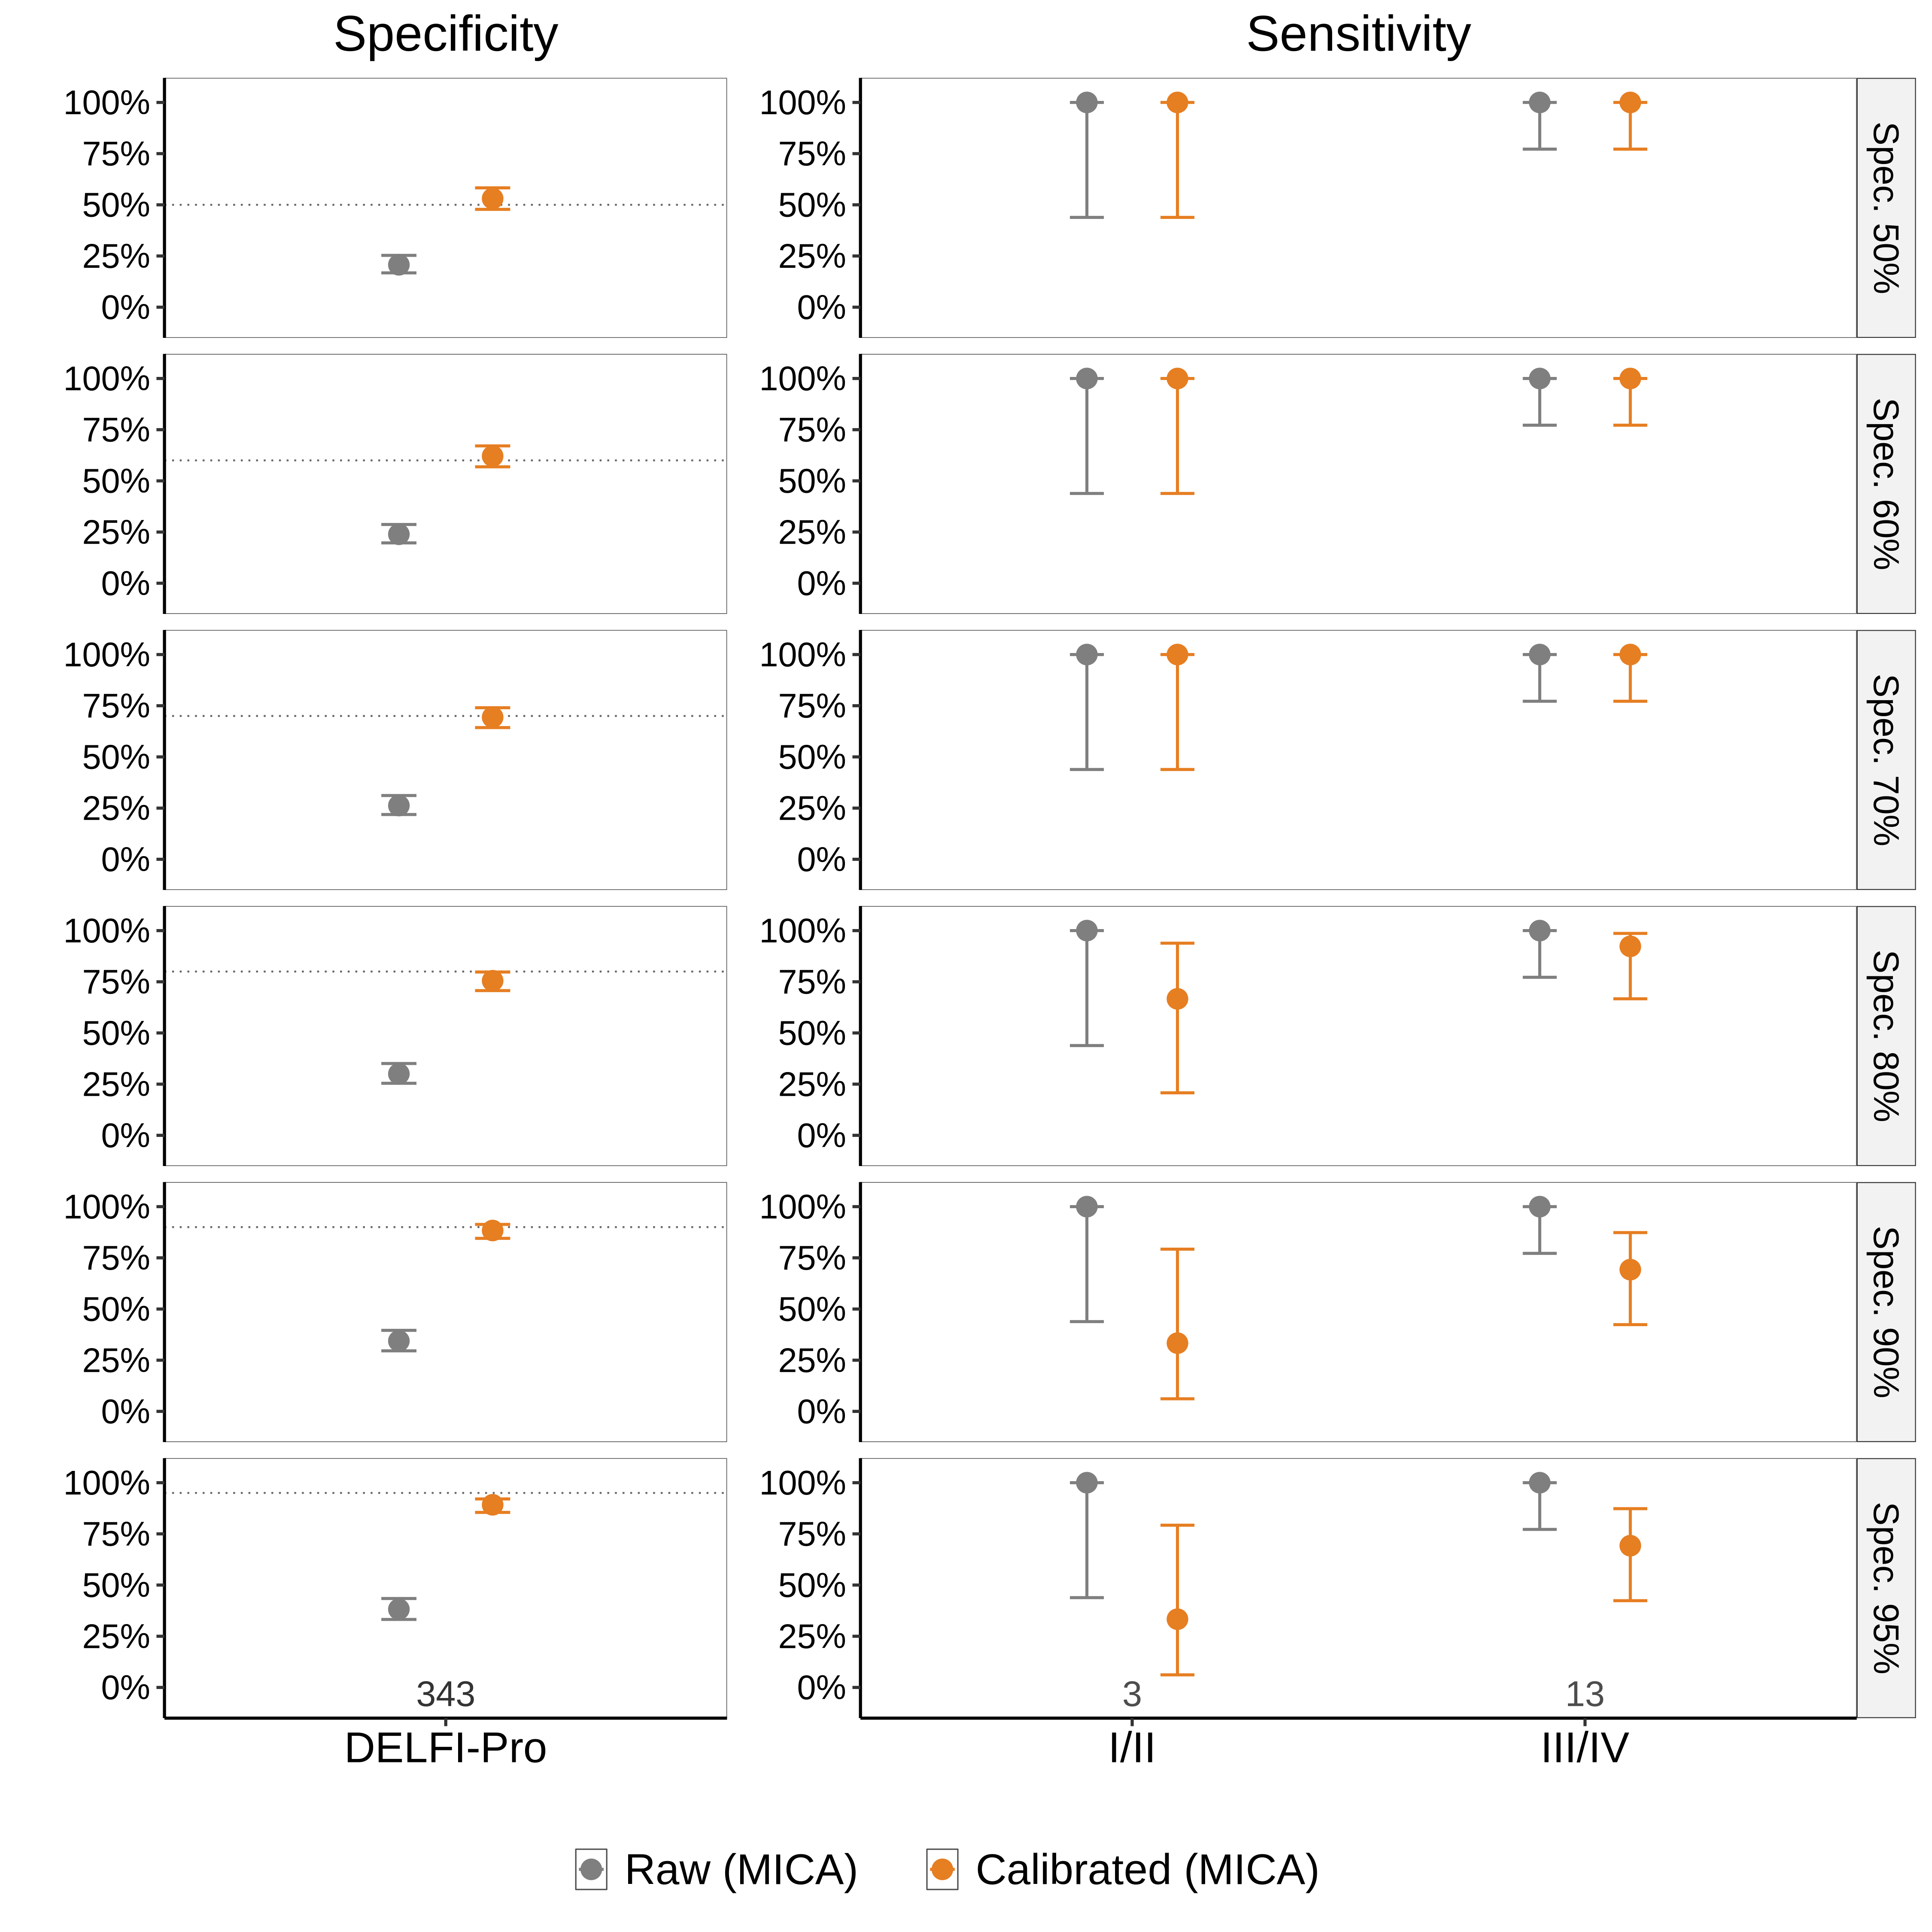

In [13]:
# =====================================================================
# Raw vs. Calibrated MICA performance, in the style of
# create_combined_validation_figure()
# =====================================================================

create_raw_vs_calibrated_figure <- function(
    mica_val_raw, mica_val_calibrated,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95),
    model_name = "DELFI-Pro",
    score_col = "score.seq.olink",
    se_level = 0.80,
    plot_width = 12,
    plot_height = 12
) {
    spec_label <- function(cutoff) paste0("Spec. ", round(cutoff * 100), "%")

    alpha          <- 1 - se_level
    lower_quantile <- alpha / 2
    upper_quantile <- 1 - alpha / 2
    conf_level     <- 2 * upper_quantile - 1

    add_stage_combined <- function(df) {
        df %>% mutate(
            stage_combined = case_when(
                class == "No cancer"          ~ NA_character_,
                stage %in% c("I", "II")       ~ "I/II",
                stage %in% c("III", "IV")     ~ "III/IV",
                TRUE                          ~ NA_character_
            )
        )
    }
    val_sets <- list(
        "Raw (MICA)"        = add_stage_combined(mica_val_raw),
        "Calibrated (MICA)" = add_stage_combined(mica_val_calibrated)
    )

    overall <- bind_rows(dat1, dat2, dat3) %>%
        mutate(training_model = factor(training_model, model_levels)) %>%
        left_join(clindat, by = "lab_id") %>%
        mutate(class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
               class = factor(class, c("No cancer", "Cancer")))
    overall.list <- split(overall, overall$training_model)
    model_idx <- 3

    evaluate_at_threshold <- function(data, sc, threshold) {
        scores <- data %>%
            select(class, stage = stage_combined, score = !!sym(sc)) %>%
            filter(!is.na(score))

        nocancer <- scores %>% filter(class == "No cancer")
        n_nc <- nrow(nocancer); tn <- sum(nocancer$score < threshold)
        spec_ci <- prop.test(tn, n_nc, conf.level = conf_level, correct = FALSE)

        stage_perf <- scores %>%
            filter(class == "Cancer", !is.na(stage)) %>%
            group_by(stage) %>%
            summarise(n = n(), tp = sum(score >= threshold), .groups = "drop") %>%
            rowwise() %>%
            mutate(ci = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE)),
                   sens = ci$estimate, lower = ci$conf.int[1], upper = ci$conf.int[2]) %>%
            select(-ci) %>% ungroup()

        bind_rows(
            tibble(stage = "0", value = unname(spec_ci$estimate), n = n_nc,
                   lower = spec_ci$conf.int[1], upper = spec_ci$conf.int[2],
                   statistic = "Specificity"),
            stage_perf %>% transmute(stage, value = sens, n, lower, upper,
                                      statistic = "Sensitivity")
        )
    }

    all_perf <- list()
    for (spec_cutoff in specificity_cutoffs) {
        lucas_roc_data <- overall.list[[model_idx]] %>% select(score, class)
        tmp <- pROC::roc(class ~ score, data = lucas_roc_data, quiet = TRUE)
        locked_threshold <- tibble(spec = tmp$specificities, thr = tmp$thresholds) %>%
            filter(spec >= spec_cutoff) %>% arrange(spec) %>% slice(1) %>% pull(thr)

        for (val_name in names(val_sets)) {
            perf <- evaluate_at_threshold(val_sets[[val_name]], score_col, locked_threshold) %>%
                mutate(dataset = val_name, specificity_cutoff = spec_cutoff,
                       specificity_label = spec_label(spec_cutoff))
            all_perf[[paste(spec_cutoff, val_name, sep = "_")]] <- perf
        }
    }

    combined_perf <- bind_rows(all_perf) %>%
        mutate(
            dataset = factor(dataset, levels = c("Raw (MICA)", "Calibrated (MICA)")),
            stage = factor(stage, c("0", "I/II", "III/IV")),
            statistic = factor(statistic, c("Specificity", "Sensitivity")),
            specificity_label = factor(specificity_label,
                                        levels = spec_label(sort(specificity_cutoffs))),
            stage0 = as.character(stage),
            stage0 = ifelse(stage0 == "0", "Non-Cancer", stage0),
            stage0 = factor(stage0, c("Non-Cancer", "I/II", "III/IV"))
        )

    spec_perf <- combined_perf %>% filter(statistic == "Specificity") %>%
        mutate(x_label = factor(model_name, levels = model_name))
    sens_perf <- combined_perf %>% filter(statistic == "Sensitivity") %>%
        mutate(x_label = factor(as.character(stage0), levels = c("I/II", "III/IV")))

    highest_spec_label <- spec_label(max(specificity_cutoffs))

    # ---- single, centered N label, only in the bottom (highest-spec) facet ----
    spec_N <- spec_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        distinct(x_label, n, specificity_label)

    sens_N <- sens_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        distinct(x_label, n, specificity_label)

    hline_data <- tibble(
        specificity_label = factor(spec_label(specificity_cutoffs),
                                    levels = spec_label(sort(specificity_cutoffs))),
        yintercept = specificity_cutoffs
    )

    dataset_colors <- c("Raw (MICA)" = "gray50", "Calibrated (MICA)" = "#e67e22")

    shared_theme <- theme_classic(base_size = 18) +
        theme(panel.grid = element_blank(),
              panel.background = element_rect(fill = "white", color = "gray30"),
              strip.background = element_rect(fill = "gray95", color = "gray30", linewidth = 0.5),
              strip.text.y.right = element_text(angle = 270, size = 19, color = "black"),
              rect = element_blank(), axis.text = element_text(size = 19, color = "black"),
              axis.title.x = element_blank(), axis.title.y = element_text(size = 24))

    shared_y_scale <- scale_y_continuous(breaks = seq(0, 1, 0.25),
                                          labels = scales::percent_format(accuracy = 1),
                                          limits = c(-0.15, 1.10),
                                          expand = expansion(add = c(0, 0.02)))

    dodge_width <- position_dodge(width = 0.4)

    p_spec <- ggplot(spec_perf, aes(x = x_label, y = value, group = dataset)) +
        geom_hline(data = hline_data, aes(yintercept = yintercept),
                   linetype = "dotted", color = "gray40", linewidth = 0.5) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = spec_N, aes(x = x_label, y = -0.03, label = n),
                  inherit.aes = FALSE, color = "gray20", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(legend.position = "none", strip.text.y.right = element_blank(),
              strip.background = element_blank(), axis.text.x = element_text(size = 24)) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale + ylab(" ") + ggtitle("Specificity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    p_sens <- ggplot(sens_perf, aes(x = x_label, y = value, group = dataset)) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = sens_N, aes(x = x_label, y = -0.03, label = n),
                  inherit.aes = FALSE, color = "gray30", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(legend.position = "bottom", legend.direction = "horizontal",
              legend.text = element_text(size = 22),
              strip.background = element_rect(fill = "gray95", color = "gray20", linewidth = 0.5),
              strip.text.y.right = element_text(angle = 270, size = 20, color = "black"),
              strip.placement = "outside", axis.text.x = element_text(size = 24),
              axis.title.y = element_blank()) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale + guides(color = guide_legend(title = "", ncol = 1)) +
        ggtitle("Sensitivity") + theme(plot.title = element_text(hjust = 0.5, size = 28))

    legend <- get_legend(
        p_sens + theme(legend.position = "bottom", legend.direction = "horizontal",
                       legend.text = element_text(size = 24, margin = margin(l = 10, r = 30, unit = "pt")),
                       legend.box.margin = margin(t = 10), legend.spacing.x = unit(2.0, "cm")) +
            guides(color = guide_legend(title = "", nrow = 1,
                                         override.aes = list(size = 5), byrow = TRUE))
    )

    p_spec <- p_spec + theme(legend.position = "none")
    p_sens <- p_sens + theme(legend.position = "none")

    plot_row <- plot_grid(p_spec, p_sens, nrow = 1, rel_widths = c(1, 1.6), align = "h", axis = "tb")
    plot_grid(plot_row, legend, ncol = 1, rel_heights = c(1, 0.08))
}

# =====================================================================
# Usage
# =====================================================================
fig_raw_vs_calibrated <- create_raw_vs_calibrated_figure(
    mica_val_raw = mica_val_raw,
    mica_val_calibrated = mica_val,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95),
    model_name = "DELFI-Pro",
    score_col = "score.seq.olink",
    se_level = 0.95
)

options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 300)

fig_raw_vs_calibrated

ggsave("../../outputs/Extended/Supple-Fig-9_Raw_vs_Calibrated_MICA.png",
       plot = fig_raw_vs_calibrated, width = 10, height = 14, dpi = 600)


In [14]:
## ---- Specificity at LUCAS-locked 60% threshold: raw vs calibrated -------
mica_val_calibrated <- mica_val

spec_at_threshold <- function(df, score_col, threshold) {
    df %>% filter(class == "No cancer") %>%
        summarise(n = n(), spec = mean(.data[[score_col]] < threshold, na.rm = TRUE)) %>%
        pull(spec, name = NULL) -> s
    s
}

nc_raw  <- mica_val_raw_matched %>% filter(class == "No cancer")
nc_cal  <- mica_val_calibrated  %>% filter(class == "No cancer")

spec_raw <- mean(nc_raw$score.seq.olink < locked_threshold, na.rm = TRUE)
spec_cal <- mean(nc_cal$score.seq.olink < locked_threshold, na.rm = TRUE)

cat(sprintf("Uncalibrated MICA specificity @ 60%%-locked threshold: %.1f%% (n=%d)\n",
            100 * spec_raw, nrow(nc_raw)))
cat(sprintf("Calibrated MICA specificity @ 60%%-locked threshold:   %.1f%% (n=%d)\n",
            100 * spec_cal, nrow(nc_cal)))

Uncalibrated MICA specificity @ 60%-locked threshold: 23.9% (n=344)
Calibrated MICA specificity @ 60%-locked threshold:   62.1% (n=344)


In [15]:
# =====================================================================
# Sensitivity of calibration performance to calibration-set size
# Bootstrap resampling (with replacement) at each size.
#
# NOTE on the n=40 arm: sampling 40 from 40 WITH replacement is a bootstrap
# of the calibration set, not the calibration set itself. It estimates how
# much the observed specificity would vary under resampling, so the boxplot
# will not centre exactly on the observed value — that value is marked
# separately in red for reference.
# =====================================================================

CAL_SIZES <- c(10, 20, 30, 40)
N_REPS    <- 1000

# observed specificity at the locked threshold, using the actual (unresampled)
# 40-sample mapper — this is the 62.1% reported in the calibration cell
spec_observed <- mica_val %>%
    filter(class == "No cancer") %>%
    summarise(s = mean(score.seq.olink < locked_thr_60, na.rm = TRUE)) %>%
    pull(s)

cat(sprintf("Observed calibrated specificity @ locked threshold (%.4f): %.1f%%\n\n",
            locked_thr_60, 100 * spec_observed))

## ---- one resample: rebuild mapper at a given calibration-set size -------
calibration_size_replicate <- function(cal_size, threshold) {
    idx        <- sample.int(nrow(mica_cal_nocancer), size = cal_size, replace = TRUE)
    cal_subset <- mica_cal_nocancer[idx, ]

    # suppressWarnings: approx() warns about non-unique x values whenever
    # n_quantiles oversamples a small empirical distribution
    mapper <- suppressWarnings(build_quantile_mapper(
        source_scores    = cal_subset$score.seq.olink.test,
        reference_scores = lucas_nocancer_seq_olink
    ))

    val_calibrated <- mica_val_raw_matched %>%
        mutate(score_cal = suppressWarnings(mapper(score.seq.olink)))

    cal_range <- range(cal_subset$score.seq.olink.test, na.rm = TRUE)
    n_clamped <- sum(mica_val_raw_matched$score.seq.olink < cal_range[1] |
                     mica_val_raw_matched$score.seq.olink > cal_range[2], na.rm = TRUE)

    ctrl <- val_calibrated %>% filter(class == "No cancer")
    case <- val_calibrated %>% filter(class == "Cancer")

    tibble(cal_size    = cal_size,
           spec        = mean(ctrl$score_cal <  threshold, na.rm = TRUE),
           sens        = mean(case$score_cal >= threshold, na.rm = TRUE),
           n_clamped   = n_clamped,
           pct_clamped = n_clamped / nrow(mica_val_raw_matched),
           n_na_scores = sum(is.na(val_calibrated$score_cal)))
}

## ---- run across all sizes x repeats -------------------------------------
set.seed(1234)
cal_size_results <- map_dfr(CAL_SIZES, function(sz) {
    map_dfr(1:N_REPS, ~ calibration_size_replicate(sz, locked_thr_60))
})

## ---- flag / report failed resamples before summarizing -------------------
n_failed <- cal_size_results %>%
    group_by(cal_size) %>%
    summarise(n_na_spec = sum(is.na(spec)), n_na_sens = sum(is.na(sens)),
              total_reps = n(), .groups = "drop")
print(as.data.frame(n_failed), row.names = FALSE)

## ---- summarize: median + 95% interval at each size, dropping NAs ---------
cal_size_summary <- cal_size_results %>%
    group_by(cal_size) %>%
    summarise(
        spec_median    = median(spec, na.rm = TRUE),
        spec_lo        = quantile(spec, 0.025, na.rm = TRUE),
        spec_hi        = quantile(spec, 0.975, na.rm = TRUE),
        sens_median    = median(sens, na.rm = TRUE),
        sens_lo        = quantile(sens, 0.025, na.rm = TRUE),
        sens_hi        = quantile(sens, 0.975, na.rm = TRUE),
        clamped_median = median(pct_clamped, na.rm = TRUE) * 100,
        n_valid        = sum(!is.na(spec)),
        .groups = "drop"
    )
print(as.data.frame(cal_size_summary), row.names = FALSE, digits = 3)


Observed calibrated specificity @ locked threshold (0.1455): 62.1%

 cal_size n_na_spec n_na_sens total_reps
       10         0         0       1000
       20         0         0       1000
       30         0         0       1000
       40         0         0       1000
 cal_size spec_median spec_lo spec_hi sens_median sens_lo sens_hi
       10       0.598   0.329   0.796           1   0.812       1
       20       0.603   0.452   0.732           1   0.875       1
       30       0.612   0.478   0.714           1   0.938       1
       40       0.621   0.504   0.703           1   1.000       1
 clamped_median n_valid
           22.8    1000
           13.9    1000
           12.8    1000
            7.5    1000


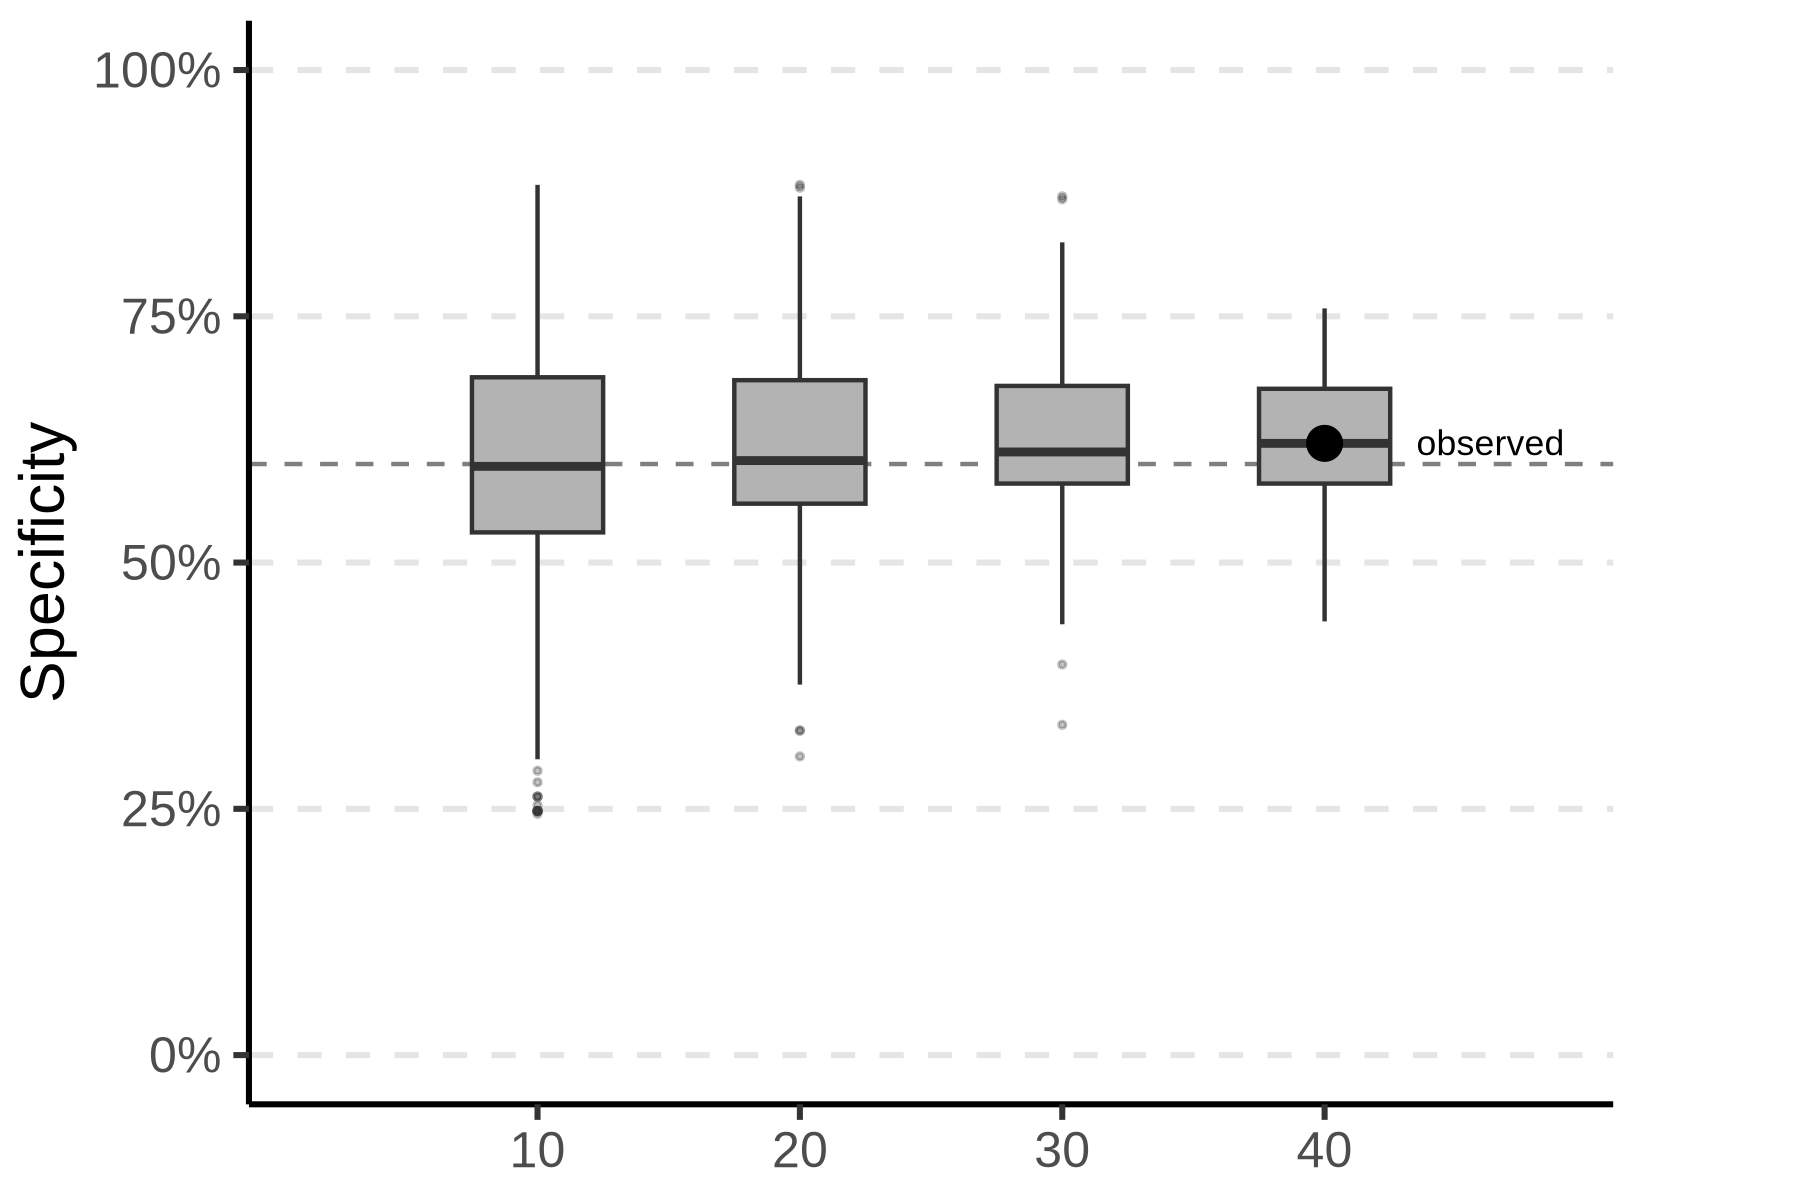

In [16]:
pStability <- cal_size_results %>%
    filter(!is.na(spec)) %>%
    ggplot(aes(factor(cal_size), spec)) +
    geom_hline(yintercept = 0.60, linetype = "dashed", color = "gray50") +
    geom_boxplot(width = 0.5, fill = "gray70", outlier.size = 0.5, outlier.alpha = 0.3) +
    geom_point(data = tibble(cal_size = 40, spec = spec_observed),
               color = "black", size = 3.5) +
    annotate("text", x = 4.35, y = spec_observed,
             label = "observed", color = "black", size = 3, hjust = 0) +
    scale_y_continuous("Specificity", labels = scales::percent_format(accuracy = 1),
                       limits = c(0, 1), breaks = seq(0, 1, 0.25)) +
    labs(x = NULL) +
    coord_cartesian(xlim = c(0.5, 4.5), clip = "off") +
    theme_classic(base_size = 15) +
    theme(panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"),
          plot.margin = margin(5, 45, 5, 5))

fig_cal_size <- pStability

options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 300)

fig_cal_size

ggsave("../../outputs/Extended/Supple-Fig-9_Calibration_Size_Sensitivity.png",
       plot = fig_cal_size, width = 6, height = 4, dpi = 600)

In [ ]:
# Done #